In [10]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt

raw = yf.download("SPY", start="2025-01-01", end="2026-01-01")
data = raw.droplevel("Ticker", axis=1)
data['daily_return'] = data['Close'].pct_change()

mu = data['daily_return'].mean()
sigma = data['daily_return'].std()
S0 = data['Close'].iloc[-1]


np.random.seed(42)
n_simulations = 1000
n_days = 252
all_paths = []

for i in range(n_simulations):
    random_returns = np.random.normal(mu, sigma, n_days)
    path = [S0]
    for r in random_returns:
        path.append(path[-1] * (1 + r))
    all_paths.append(path)
    
all_paths = np.array(all_paths)
final_prices = all_paths[:, -1]

[*********************100%***********************]  1 of 1 completed


In [13]:
strike = 700
r_free = 0.05
T = 1

discount_factor = np.exp(-r_free * T)
r_daily = r_free / 252
np.random.seed(42)
all_paths_rn = []

for i in range(n_simulations):
    random_returns_rn = np.random.normal(r_daily, sigma, n_days)
    path_rn = [S0]
    for r in random_returns_rn:
        path_rn.append(path_rn[-1] * (1 + r))
    all_paths_rn.append(path_rn)

all_paths_rn = np.array(all_paths_rn)
final_prices_rn = all_paths_rn[:, -1]
payoff_rn = np.maximum(final_prices_rn - strike, 0)
option_premium = payoff_rn.mean() * discount_factor

print(f"Option premium : ${option_premium:.2f}")

Option premium : $58.78


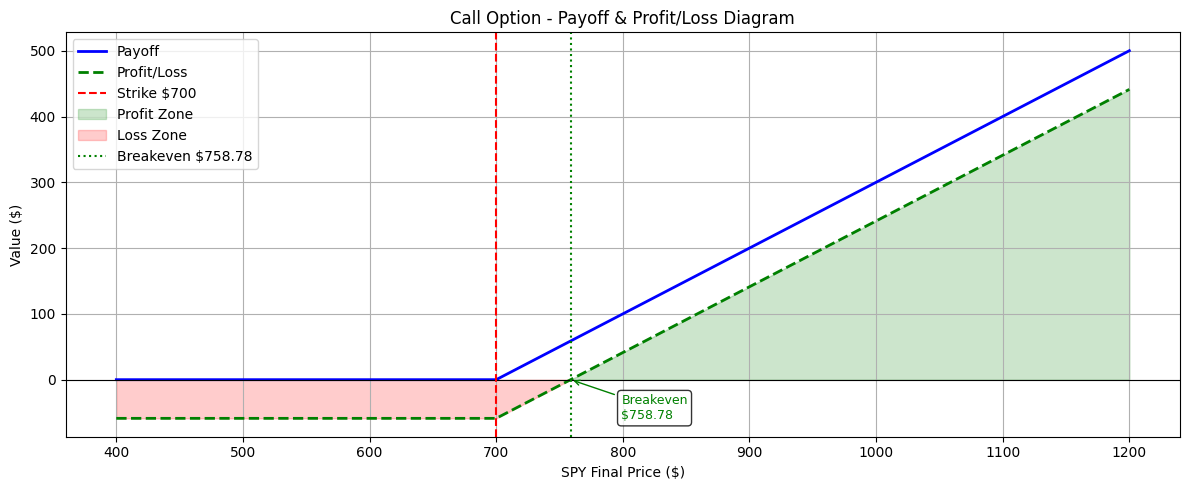

In [23]:
price_range = np.linspace(400, 1200, 500)

payoff = np.maximum(price_range - strike, 0)
profit = payoff - option_premium

fig, ax = plt.subplots(figsize=(12,5))
ax.plot(price_range, payoff, 'b-', linewidth=2, label='Payoff')
ax.plot(price_range, profit, 'g--', linewidth=2, label='Profit/Loss')
ax.axhline(y=0, color='black', linewidth=0.8)
ax.axvline(x=strike, color='red', linestyle='--', linewidth=1.5, label=f'Strike ${strike}')
ax.fill_between(price_range, profit, 0,
                where=(profit > 0), alpha=0.2, color='green', label='Profit Zone')
ax.fill_between(price_range, profit, 0,
                where=(profit < 0), alpha=0.2, color='red', label='Loss Zone')
ax.set_title("Call Option - Payoff & Profit/Loss Diagram")
ax.set_xlabel("SPY Final Price ($)")
ax.set_ylabel("Value ($)")

breakeven = strike + option_premium
ax.axvline(x=breakeven, color='green', linestyle=':',
           linewidth=1.5, label=f'Breakeven ${breakeven:.2f}')
ax.annotate(f'Breakeven\n${breakeven:.2f}',
            xy=(breakeven, 0),
            xytext=(breakeven+40, -60),
            fontsize=9,
            arrowprops=dict(arrowstyle='->', color='green'),
            color='green',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()